In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(fr"C:\Users\Noodl\Study Materials\MLLab\10-dataset (1).csv")

In [3]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [14]:
X = np.c_[np.ones(len(data)), data.total_bill]

In [15]:
X

array([[ 1.  , 16.99],
       [ 1.  , 10.34],
       [ 1.  , 21.01],
       [ 1.  , 23.68],
       [ 1.  , 24.59],
       [ 1.  , 25.29],
       [ 1.  ,  8.77],
       [ 1.  , 26.88],
       [ 1.  , 15.04],
       [ 1.  , 14.78],
       [ 1.  , 10.27],
       [ 1.  , 35.26],
       [ 1.  , 15.42],
       [ 1.  , 18.43],
       [ 1.  , 14.83],
       [ 1.  , 21.58],
       [ 1.  , 10.33],
       [ 1.  , 16.29],
       [ 1.  , 16.97],
       [ 1.  , 20.65],
       [ 1.  , 17.92],
       [ 1.  , 20.29],
       [ 1.  , 15.77],
       [ 1.  , 39.42],
       [ 1.  , 19.82],
       [ 1.  , 17.81],
       [ 1.  , 13.37],
       [ 1.  , 12.69],
       [ 1.  , 21.7 ],
       [ 1.  , 19.65],
       [ 1.  ,  9.55],
       [ 1.  , 18.35],
       [ 1.  , 15.06],
       [ 1.  , 20.69],
       [ 1.  , 17.78],
       [ 1.  , 24.06],
       [ 1.  , 16.31],
       [ 1.  , 16.93],
       [ 1.  , 18.69],
       [ 1.  , 31.27],
       [ 1.  , 16.04],
       [ 1.  , 17.46],
       [ 1.  , 13.94],
       [ 1.

In [16]:
y = data.tip.values

In [17]:
y

array([ 1.01,  1.66,  3.5 ,  3.31,  3.61,  4.71,  2.  ,  3.12,  1.96,
        3.23,  1.71,  5.  ,  1.57,  3.  ,  3.02,  3.92,  1.67,  3.71,
        3.5 ,  3.35,  4.08,  2.75,  2.23,  7.58,  3.18,  2.34,  2.  ,
        2.  ,  4.3 ,  3.  ,  1.45,  2.5 ,  3.  ,  2.45,  3.27,  3.6 ,
        2.  ,  3.07,  2.31,  5.  ,  2.24,  2.54,  3.06,  1.32,  5.6 ,
        3.  ,  5.  ,  6.  ,  2.05,  3.  ,  2.5 ,  2.6 ,  5.2 ,  1.56,
        4.34,  3.51,  3.  ,  1.5 ,  1.76,  6.73,  3.21,  2.  ,  1.98,
        3.76,  2.64,  3.15,  2.47,  1.  ,  2.01,  2.09,  1.97,  3.  ,
        3.14,  5.  ,  2.2 ,  1.25,  3.08,  4.  ,  3.  ,  2.71,  3.  ,
        3.4 ,  1.83,  5.  ,  2.03,  5.17,  2.  ,  4.  ,  5.85,  3.  ,
        3.  ,  3.5 ,  1.  ,  4.3 ,  3.25,  4.73,  4.  ,  1.5 ,  3.  ,
        1.5 ,  2.5 ,  3.  ,  2.5 ,  3.48,  4.08,  1.64,  4.06,  4.29,
        3.76,  4.  ,  3.  ,  1.  ,  4.  ,  2.55,  4.  ,  3.5 ,  5.07,
        1.5 ,  1.8 ,  2.92,  2.31,  1.68,  2.5 ,  2.  ,  2.52,  4.2 ,
        1.48,  2.  ,

In [21]:
def kernel(x,p,k):
    return np.diag(np.exp(np.sum((x-p)**2, axis=1)/(-2*k**2)))

In [24]:
def predict(X,y,k=0.5):
    yp = np.zeros(len(X))
    for i,p in enumerate(X):
        w=kernel(X,p,k)
        yp[i] = p @ np.linalg.inv(X.T@w@X)@X.T@w@y
    return yp

In [25]:
yp = predict(X,y)

In [26]:
yp

array([ 2.89600072,  1.79792676,  3.4522923 ,  3.52469879,  3.55735533,
        4.30366513,  1.74542033,  3.3728316 ,  2.44785581,  2.48880782,
        1.8083104 ,  4.79767983,  2.4062242 ,  2.96892092,  2.48153633,
        3.60296925,  1.79915825,  2.69663122,  2.89434019,  3.31271154,
        2.99001488,  3.16455055,  2.45092913,  5.81565108,  3.01841158,
        2.97028536,  2.25892138,  2.0276448 ,  3.60793899,  2.97252695,
        1.95484881,  2.99194322,  2.44464168,  3.32920123,  2.96499951,
        3.21755765,  2.7072132 ,  2.89066608,  2.88520305,  4.24629839,
        2.56138533,  2.92431206,  2.4541946 ,  1.95650777,  3.76134349,
        3.00455741,  3.53901817,  4.09179973,  3.66290968,  3.00808646,
        2.0045738 ,  1.80493014,  4.74741353,  1.89792722,  4.27129464,
        2.93423809,  3.43543432,  3.4808215 ,  1.94126954,  7.23057352,
        3.16455055,  2.41735695,  1.88491665,  3.00455741,  2.93692617,
        3.09292596,  2.77475539,  1.        ,  3.14256163,  2.45

In [33]:
s = X[:,1].argsort()


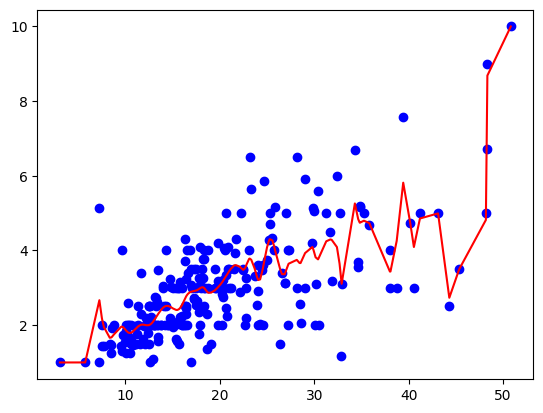

In [36]:
plt.scatter(data.total_bill, data.tip, color = 'blue')
plt.plot(X[s,1], yp[s], color='red')
plt.show()